<a href="https://colab.research.google.com/github/greeshmakrishnan00/EDA-ML-DL-Projects/blob/main/AI_WEATHER_FORECASTING_SYSTEM_PROJECT_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement

Weather forecasting is a critical process that helps governments, businesses, and individuals prepare for changing environmental conditions and potential natural disasters. With the increasing frequency of extreme weather events caused by climate change, accurate prediction of rainfall, storms, floods, and other severe weather conditions has become more important than ever. Traditional forecasting techniques often face limitations in processing large volumes of historical weather records and satellite observations, which can affect prediction accuracy and response time. The availability of advanced data analytics and artificial intelligence provides an opportunity to enhance forecasting capabilities by identifying complex patterns and relationships within weather data. This project aims to develop an AI Weather Forecasting System that utilizes historical weather parameters such as temperature, humidity, atmospheric pressure, wind speed, cloud cover, rainfall history, seasonal information, and satellite-based observations to predict the likelihood of rainfall and extreme weather conditions. By applying machine learning and deep learning algorithms, the system can learn from past weather trends and generate accurate predictions of weather risk levels. The proposed solution is intended to support early warning systems, improve disaster preparedness, assist agricultural planning, enhance transportation safety, and enable authorities to take proactive measures to reduce economic losses, infrastructure damage, and risks to human life caused by adverse weather events.
.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [ ]:
df=pd.read_csv("/content/AI_Weather_Forecasting_System_Dataset.csv")
df

,Temperature_C,Humidity_%,Pressure_hPa,WindSpeed_kmh,CloudCover_%,RainfallLast24h_mm,Season,Region,SatelliteAlert,WeatherPattern,DayPeriod,RiskScore,Weather Risk Level
0,30.98,35.18,1007.12,31.98,15.87,5.31,Summer,Mountain,High,Storm,Night,63.70,No Extreme Weather
1,27.17,59.86,1023.04,56.56,62.46,0.79,Winter,Rural,Moderate,Cloudy,Morning,50.04,No Extreme Weather
2,31.89,94.41,991.90,63.55,81.45,13.56,Monsoon,Mountain,Moderate,Storm,Afternoon,106.09,Extreme Weather
3,37.14,96.60,1009.95,33.79,58.56,3.33,Post-Monsoon,Coastal,Low,Clear,Afternoon,46.46,No Extreme Weather
4,26.60,38.48,998.47,47.94,72.10,4.61,Monsoon,Urban,Moderate,Storm,Morning,84.52,Extreme Weather
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50995,17.60,50.78,1018.84,44.63,11.31,2.91,Post-Monsoon,Urban,Low,Storm,Evening,41.48,No Extreme Weather
50996,24.31,47.80,1010.01,17.60,79.70,15.16,Post-Monsoon,Coastal,High,Clear,Evening,65.53,Extreme Weather
50997,34.76,38.30,998.71,77.18,38.20,0.04,Summer,Rural,Moderate,Clear,Morning,42.75,No Extreme Weather
50998,27.24,92.96,994.36,62.05,67.94,6.95,Monsoon,Coastal,High,Storm,Night,114.88,Extreme Weather


In [ ]:
df.isnull().sum()

,0
Temperature_C,0
Humidity_%,0
Pressure_hPa,0
WindSpeed_kmh,0
CloudCover_%,0
RainfallLast24h_mm,0
Season,0
Region,0
SatelliteAlert,0
WeatherPattern,0


In [ ]:
df.duplicated().sum()

np.int64(1000)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.columns

Index(['Temperature_C', 'Humidity_%', 'Pressure_hPa', 'WindSpeed_kmh',
       'CloudCover_%', 'RainfallLast24h_mm', 'Season', 'Region',
       'SatelliteAlert', 'WeatherPattern', 'DayPeriod', 'RiskScore',
       'Weather Risk Level'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Temperature_C       50000 non-null  float64
 1   Humidity_%          50000 non-null  float64
 2   Pressure_hPa        50000 non-null  float64
 3   WindSpeed_kmh       50000 non-null  float64
 4   CloudCover_%        50000 non-null  float64
 5   RainfallLast24h_mm  50000 non-null  float64
 6   Season              50000 non-null  object 
 7   Region              50000 non-null  object 
 8   SatelliteAlert      50000 non-null  object 
 9   WeatherPattern      50000 non-null  object 
 10  DayPeriod           50000 non-null  object 
 11  RiskScore           50000 non-null  float64
 12  Weather Risk Level  50000 non-null  object 
dtypes: float64(7), object(6)
memory usage: 5.3+ MB


In [ ]:
target='Weather Risk Level'

In [ ]:
df[target].value_counts()

,count
Weather Risk Level,
No Extreme Weather,32436
Extreme Weather,17564


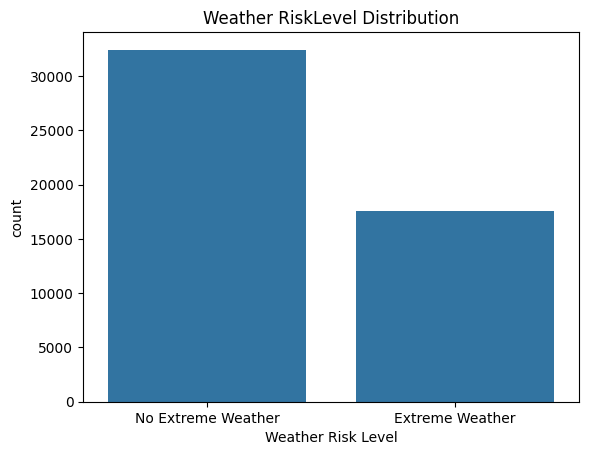

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Weather Risk Level', data=df)
plt.title('Weather RiskLevel Distribution')
plt.show()

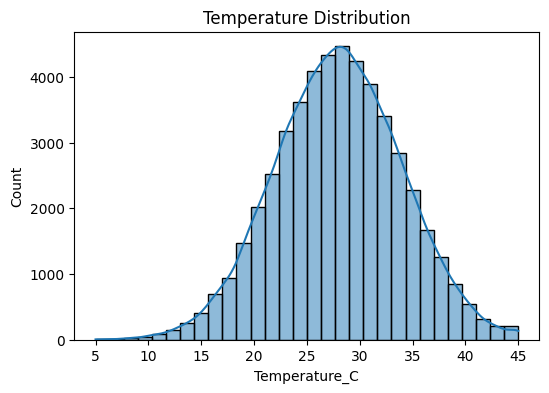

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Temperature_C'], bins=30, kde=True)
plt.title('Temperature Distribution')
plt.show()

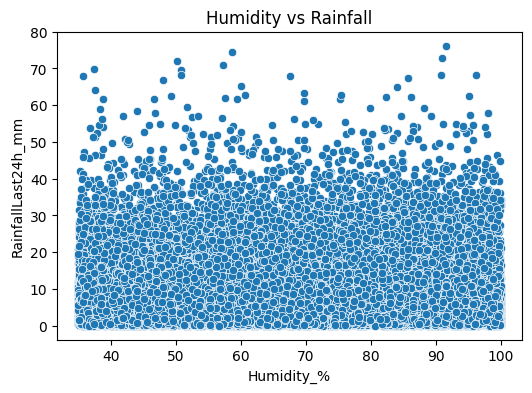

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Humidity_%', y='RainfallLast24h_mm', data=df)
plt.title('Humidity vs Rainfall')
plt.show()

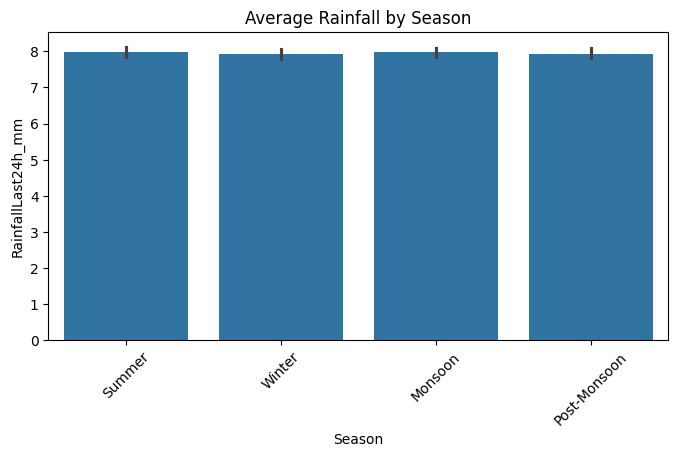

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(x='Season', y='RainfallLast24h_mm', data=df)
plt.title('Average Rainfall by Season')
plt.xticks(rotation=45)
plt.show()

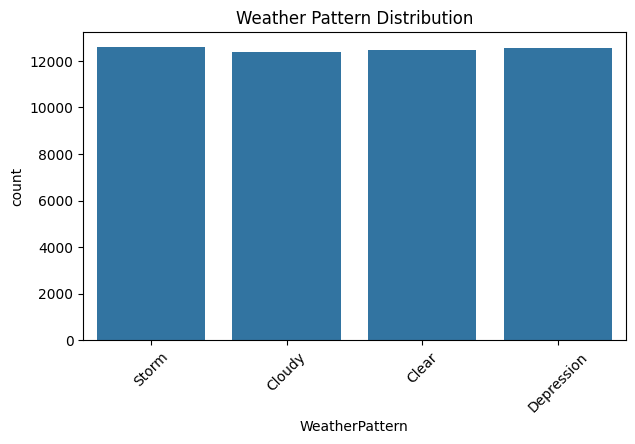

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x='WeatherPattern', data=df)
plt.title('Weather Pattern Distribution')
plt.xticks(rotation=45)
plt.show()

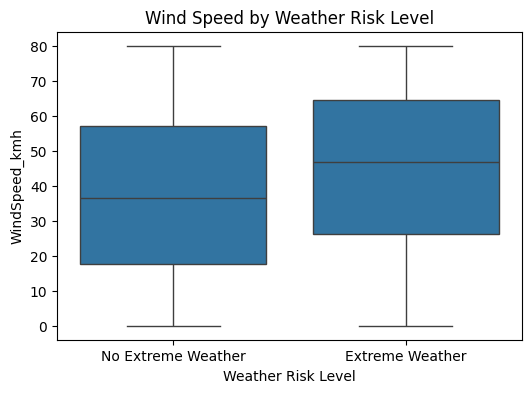

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Weather Risk Level',
            y='WindSpeed_kmh',
            data=df)

plt.title('Wind Speed by Weather Risk Level')
plt.show()

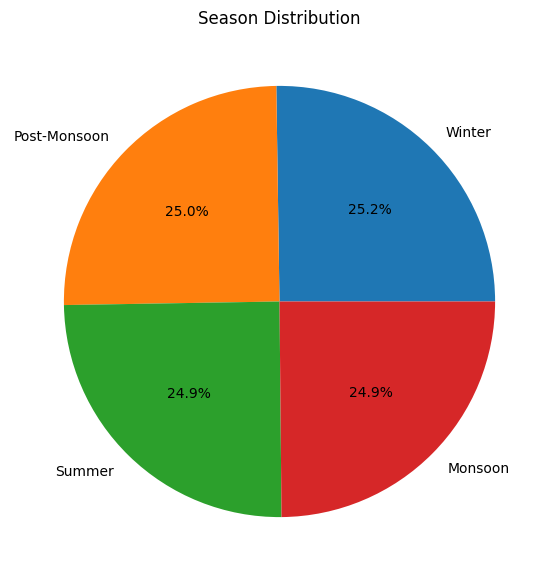

In [ ]:
plt.figure(figsize=(7,7))
df['Season'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Season Distribution')
plt.ylabel('')
plt.show()

In [ ]:
categorical_cols=df.select_dtypes(include='object').columns
categorical_cols

Index(['Season', 'Region', 'SatelliteAlert', 'WeatherPattern', 'DayPeriod',
       'Weather Risk Level'],
      dtype='object')

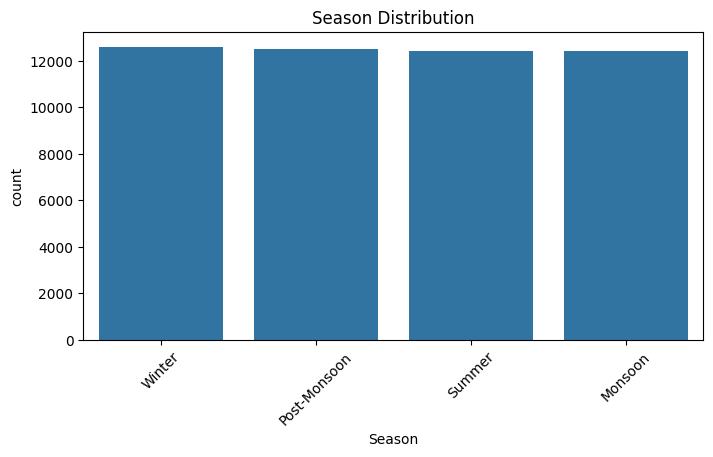

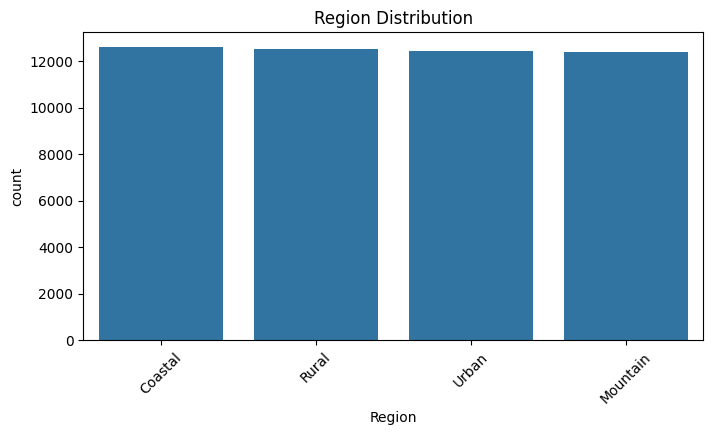

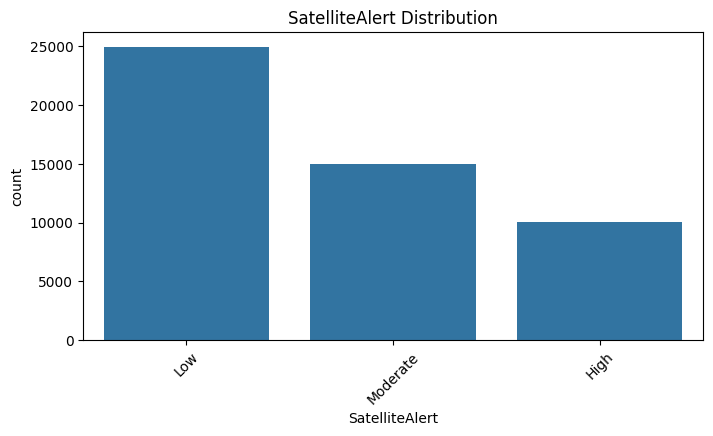

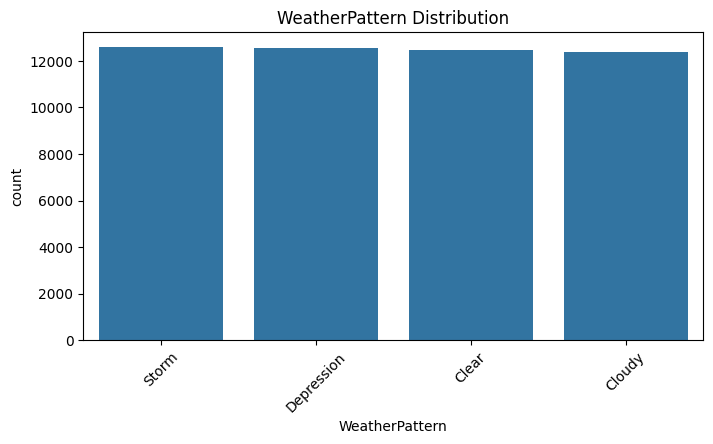

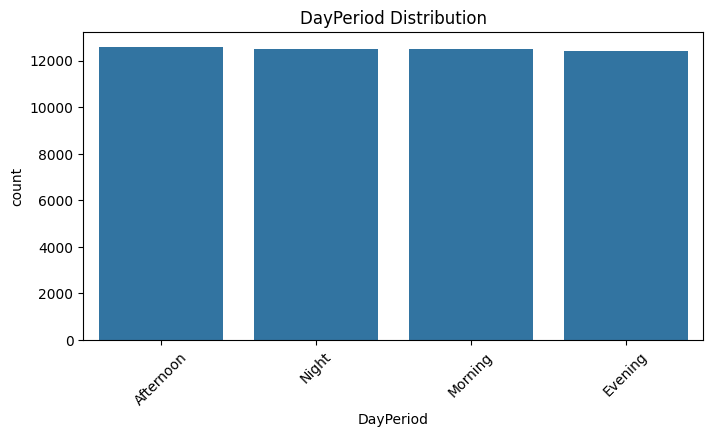

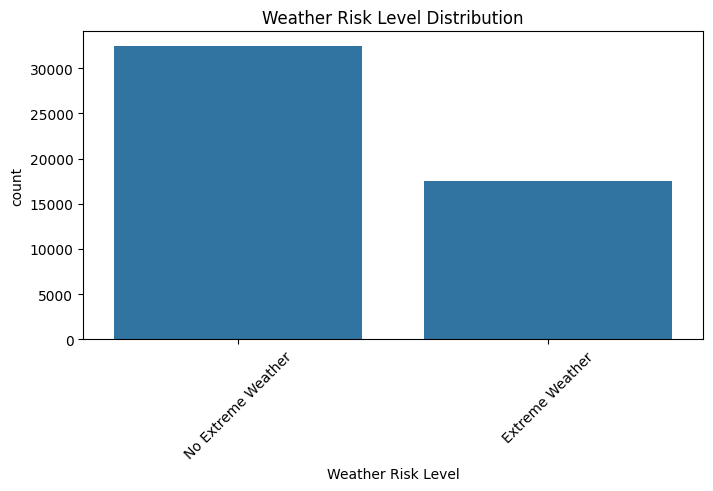

In [ ]:
for col in categorical_cols:
  plt.figure(figsize=(8,4))
  sns.countplot(x=df[col],order=df[col].value_counts().index[:10])
  plt.xticks(rotation=45)
  plt.title(f'{col} Distribution')
  plt.show()

In [ ]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['Temperature_C', 'Humidity_%', 'Pressure_hPa', 'WindSpeed_kmh',
       'CloudCover_%', 'RainfallLast24h_mm', 'RiskScore'],
      dtype='object')

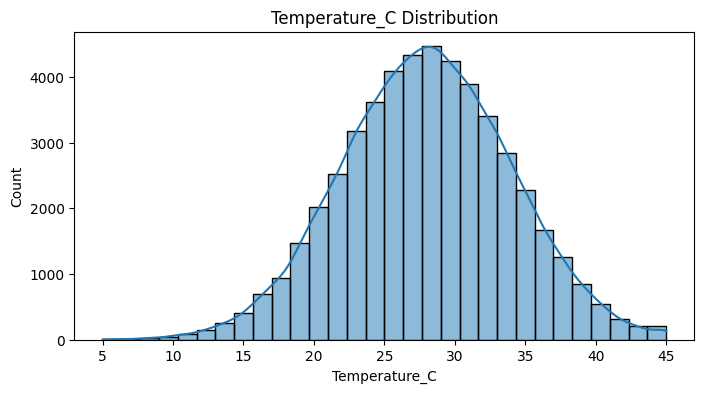

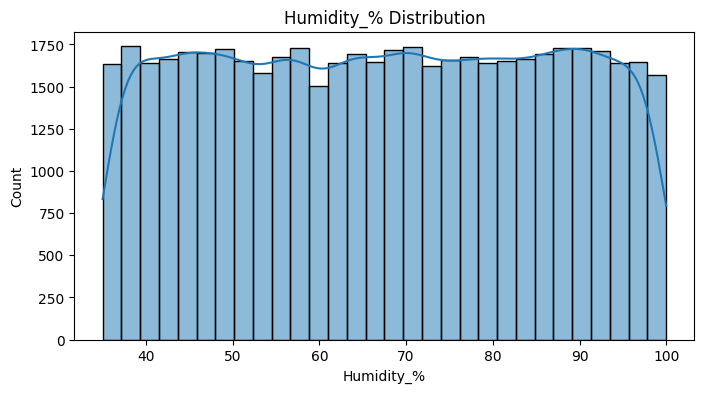

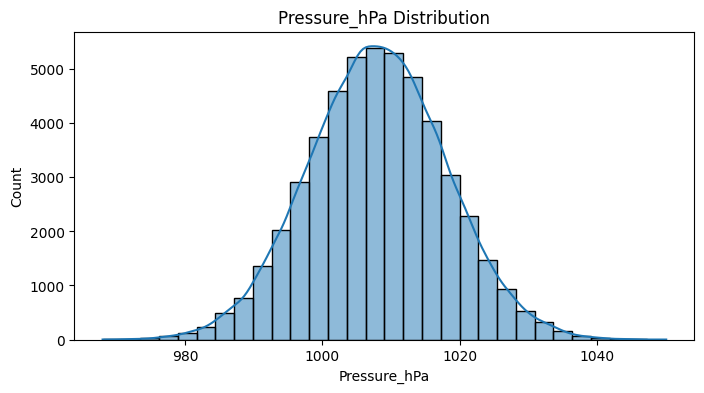

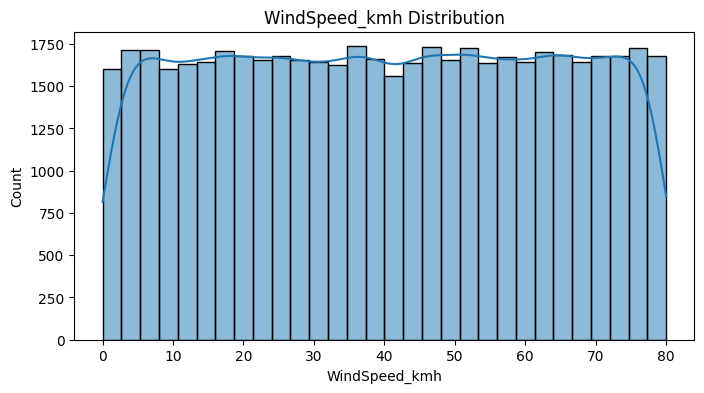

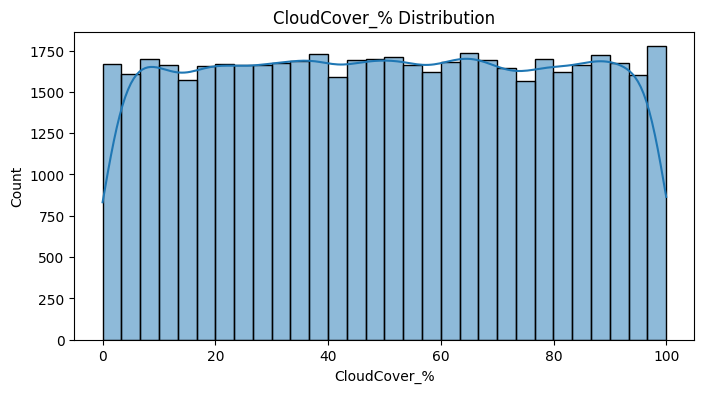

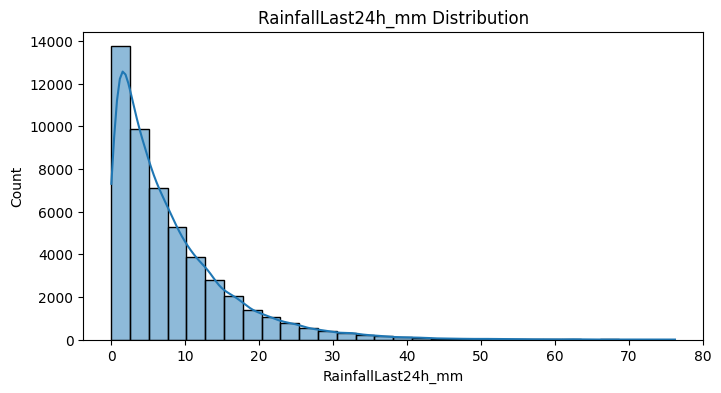

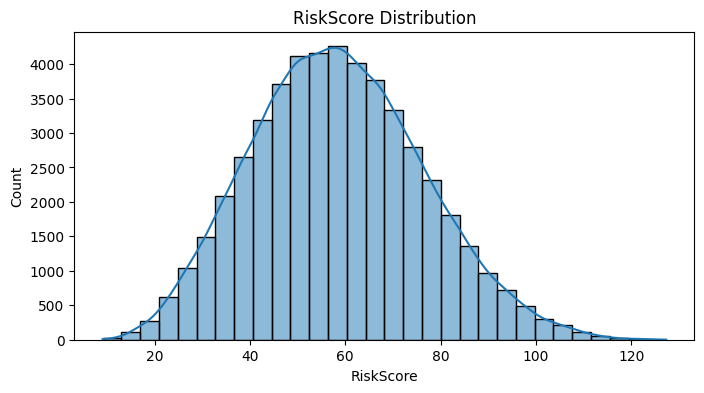

In [ ]:
for col in numeric_cols:
  plt.figure(figsize=(8,4))
  sns.histplot(df[col],bins=30,kde=True)
  plt.title(f'{col} Distribution')
  plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Season"]=le.fit_transform(df["Season"])
df["Region"]=le.fit_transform(df["Region"])
df["Weather Risk Level"]=le.fit_transform(df["Weather Risk Level"])
df["WeatherPattern"]=le.fit_transform(df["WeatherPattern"])
df["DayPeriod"]=le.fit_transform(df["DayPeriod"])

In [ ]:
df['SatelliteAlert'] = df['SatelliteAlert'].replace({
    'Low': 0,
    'Moderate': 1,
    'High': 2
})

/tmp/ipykernel_4830/3966350190.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['SatelliteAlert'] = df['SatelliteAlert'].replace({


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Temperature_C       50000 non-null  float64
 1   Humidity_%          50000 non-null  float64
 2   Pressure_hPa        50000 non-null  float64
 3   WindSpeed_kmh       50000 non-null  float64
 4   CloudCover_%        50000 non-null  float64
 5   RainfallLast24h_mm  50000 non-null  float64
 6   Season              50000 non-null  int64  
 7   Region              50000 non-null  int64  
 8   SatelliteAlert      50000 non-null  int64  
 9   WeatherPattern      50000 non-null  int64  
 10  DayPeriod           50000 non-null  int64  
 11  RiskScore           50000 non-null  float64
 12  Weather Risk Level  50000 non-null  int64  
dtypes: float64(7), int64(6)
memory usage: 5.3 MB


In [ ]:
#SMOTE (over sampling) (used to clear the inbalance, in two ways -over sampling, under sampling)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd
# Features and Target
x = df.drop('Weather Risk Level', axis=1)
y = df['Weather Risk Level']

# Apply SMOTE
smote = SMOTE(random_state=42)

x_resampled, y_resampled = smote.fit_resample(x, y)

# Combine X and Y into one DataFrame
df_resampled = pd.concat(
    [pd.DataFrame(x_resampled, columns=x.columns),
     pd.DataFrame(y_resampled, columns=['Weather Risk Level'])],
    axis=1
)

# Display balanced dataset
print(df_resampled.head())

# Check class distribution
print(df_resampled['Weather Risk Level'].value_counts())

   Temperature_C  Humidity_%  Pressure_hPa  WindSpeed_kmh  CloudCover_%  \
0          30.98       35.18       1007.12          31.98         15.87   
1          27.17       59.86       1023.04          56.56         62.46   
2          31.89       94.41        991.90          63.55         81.45   
3          37.14       96.60       1009.95          33.79         58.56   
4          26.60       38.48        998.47          47.94         72.10   

   RainfallLast24h_mm  Season  Region  SatelliteAlert  WeatherPattern  \
0                5.31       2       1               2               3   
1                0.79       3       2               1               1   
2               13.56       0       1               1               3   
3                3.33       1       0               0               0   
4                4.61       0       3               1               3   

   DayPeriod  RiskScore  Weather Risk Level  
0          3      63.70                   1  
1          2      

In [ ]:
df=df_resampled

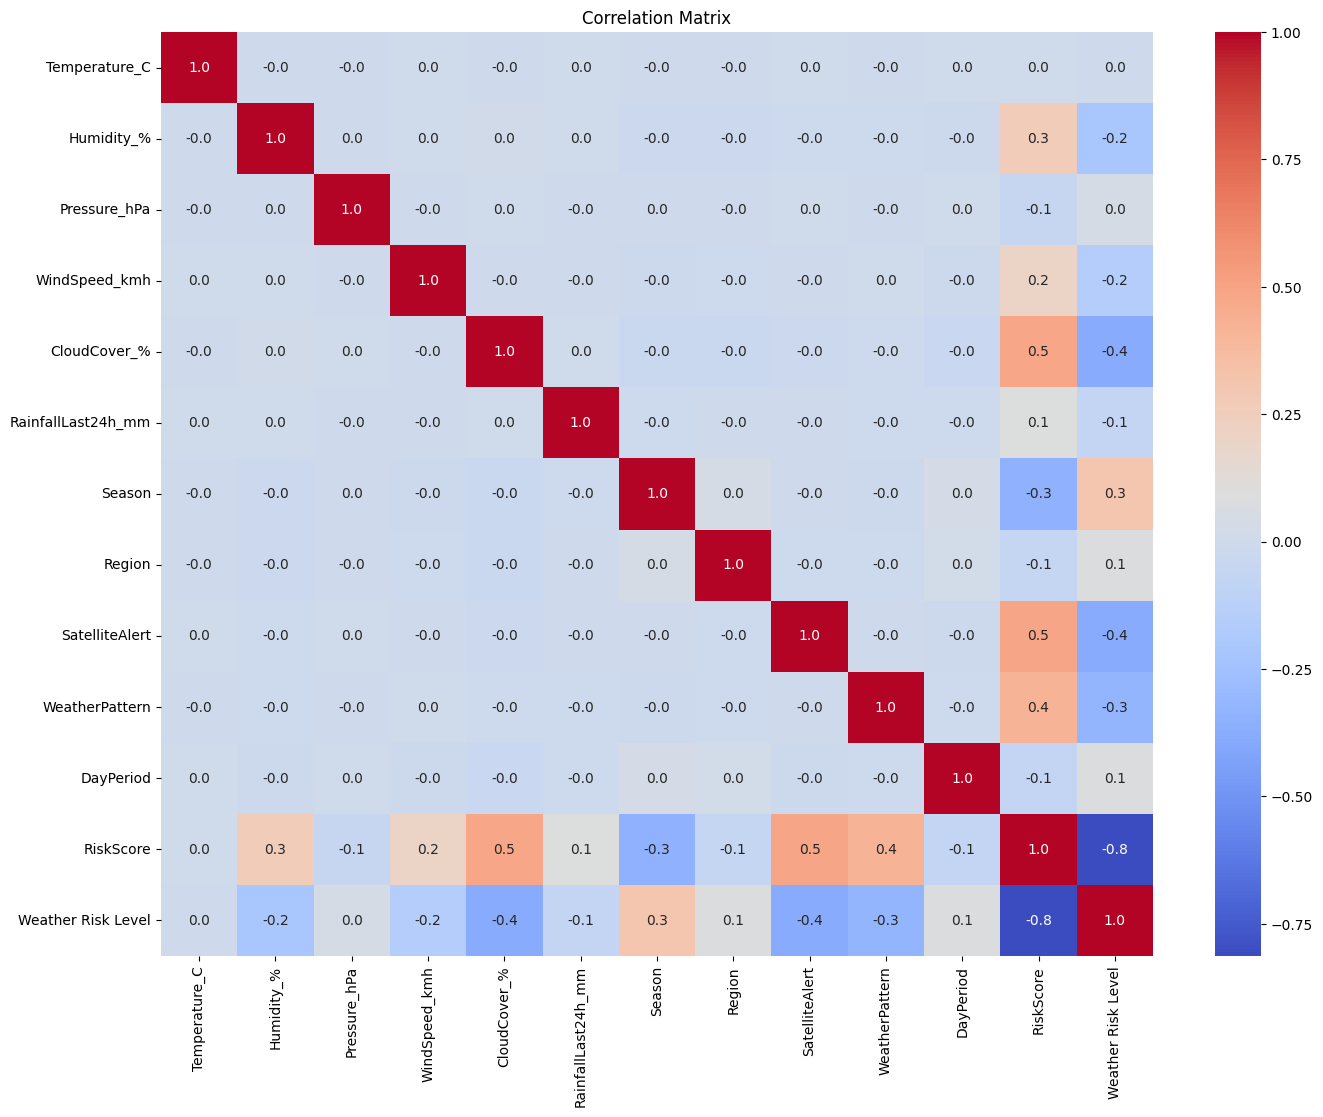

In [ ]:
core_matrix=df.corr()
plt.figure(figsize=(16,12))
sns.heatmap(core_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

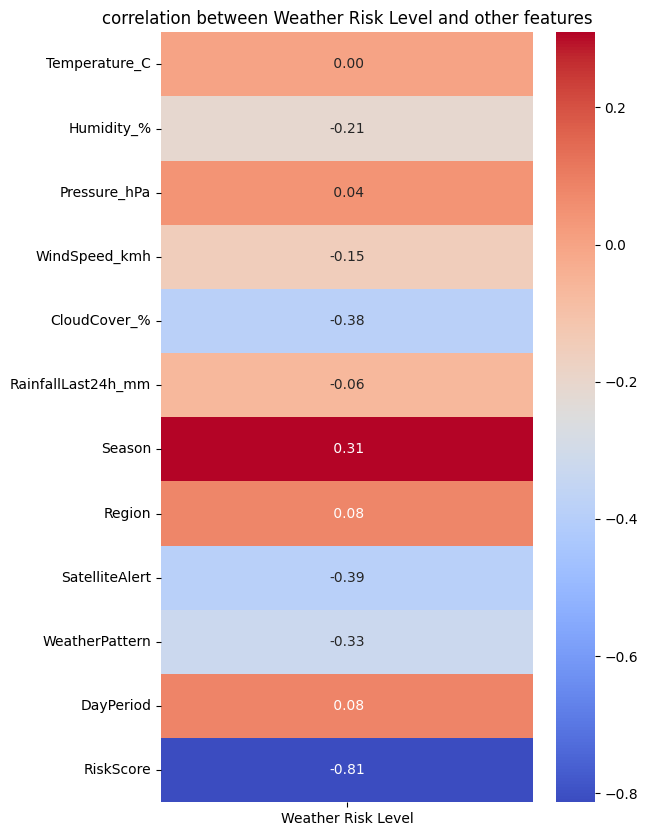

In [ ]:
plt.figure(figsize=(6,10))

status_corr=df.corr()["Weather Risk Level"]
status_corr=status_corr.drop("Weather Risk Level")
sns.heatmap(status_corr.to_frame(), annot=True,fmt=' .2f',cmap='coolwarm',cbar=True, annot_kws={'size':10})
plt.title('correlation between Weather Risk Level and other features')
plt.show()

In [ ]:
df.columns

Index(['Temperature_C', 'Humidity_%', 'Pressure_hPa', 'WindSpeed_kmh',
       'CloudCover_%', 'RainfallLast24h_mm', 'Season', 'Region',
       'SatelliteAlert', 'WeatherPattern', 'DayPeriod', 'RiskScore',
       'Weather Risk Level'],
      dtype='object')

In [ ]:
df.drop(["RiskScore","SatelliteAlert","CloudCover_%","WeatherPattern"],axis=1,inplace=True)

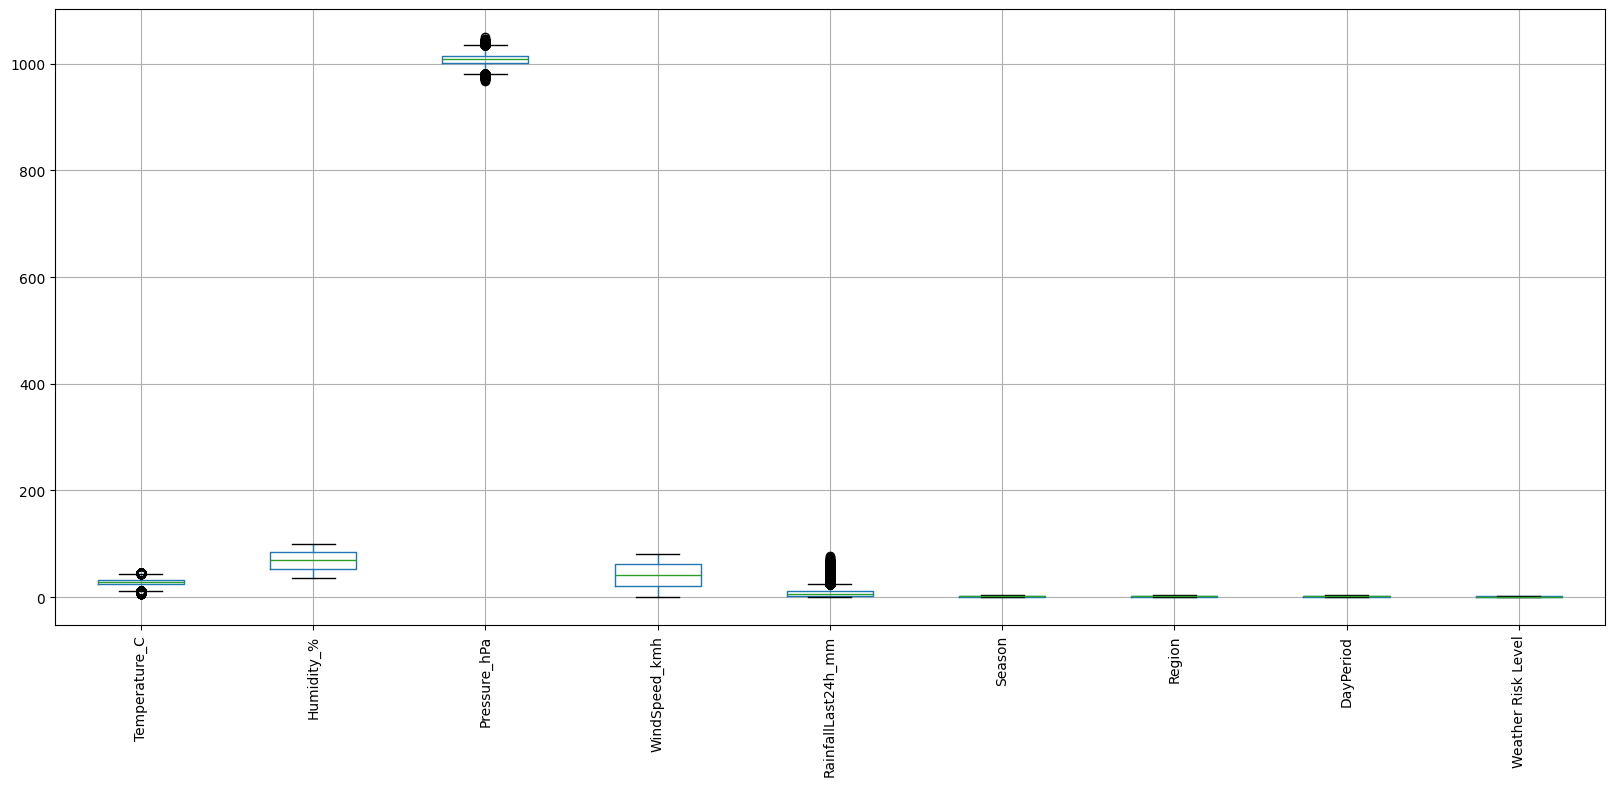

In [ ]:
df.boxplot(figsize=(20,8))
plt.xticks(rotation=90)
plt.show()

In [ ]:
def remove_outliers_iqr(df,exclude_column):
    for col in df.select_dtypes(include=['int64','float64']).columns:
        if col==exclude_column:
            continue

        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)

        IQR=Q3-Q1

        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR

        df=df[(df[col]>=lower) & (df[col]<=upper)]

    return df
df=remove_outliers_iqr(df,exclude_column=target)

In [ ]:
df.shape

(60796, 9)

In [ ]:
df.columns

Index(['Temperature_C', 'Humidity_%', 'Pressure_hPa', 'WindSpeed_kmh',
       'RainfallLast24h_mm', 'Season', 'Region', 'DayPeriod',
       'Weather Risk Level'],
      dtype='object')

In [ ]:
features=['Temperature_C', 'Humidity_%', 'Pressure_hPa', 'WindSpeed_kmh',
       'RainfallLast24h_mm', 'Season', 'Region', 'DayPeriod']
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled_data,columns=features)

In [ ]:
x=df[['Temperature_C', 'Humidity_%', 'Pressure_hPa', 'WindSpeed_kmh',
       'RainfallLast24h_mm', 'Season', 'Region', 'DayPeriod']]
y=df["Weather Risk Level"]

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=LogisticRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.68


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Machine Learning

In [ ]:
#DecisionTree

from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.62


In [ ]:
# SVC

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear'))
])

# Train
model.fit(x_train, y_train)

# Predict
y_pred = model.predict(x_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Pipeline Linear SVC Accuracy: {accuracy:.2f}")

Pipeline Linear SVC Accuracy: 0.68


In [ ]:
#Random forest

from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.71


In [ ]:
#GradientBooster

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(x_train, y_train)

y_pred_gb = gb_model.predict(x_test)

print("Gradient Boosting Accuracy:",accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.694124613461412


In [ ]:
# ADABOOST
from sklearn.ensemble import AdaBoostClassifier

model=AdaBoostClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.69


In [ ]:
#xgboost

from  xgboost import XGBClassifier

model=XGBClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.69


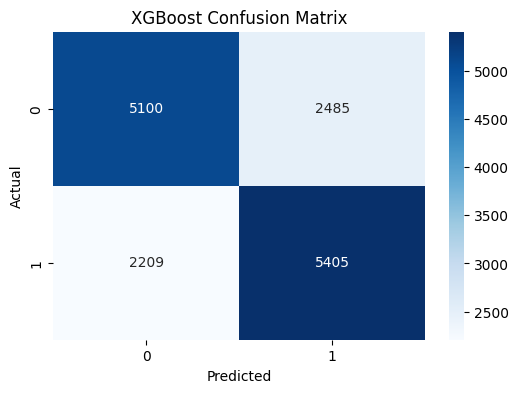

In [ ]:
#Confusion Matrix

cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# K-Fold Cross Validation

In [ ]:
X=df.drop('Weather Risk Level',axis=1)
y=df['Weather Risk Level']

kf=KFold(n_splits=5,shuffle=True,random_state=42)

model=LogisticRegression(max_iter=10000)

best_accuracy=0
best_fold=-1

best_x_train=None
best_y_train=None
best_x_test=None
best_y_test=None
best_y_pred=None

for fold,(train_index,test_index) in enumerate(kf.split(x),1):

    print(f"\nFold {fold}")

    x_train,x_test=x.iloc[train_index],x.iloc[test_index]
    y_train,y_test=y.iloc[train_index],y.iloc[test_index]

    model.fit(x_train,y_train)

    y_pred=model.predict(x_test)

    acc=accuracy_score(y_test,y_pred)

    print("Accuracy:",acc)

    if acc>best_accuracy:

        best_accuracy=acc
        best_fold=fold

        best_X_train=x_train
        best_y_train=y_train

        best_X_test=x_test
        best_y_test=y_test

        best_y_pred=y_pred

print(f"\nBest Fold: {best_fold} with Accuracy: {best_accuracy}")


Fold 1
Accuracy: 0.6775493421052632

Fold 2
Accuracy: 0.6807303232173698

Fold 3
Accuracy: 0.6730816679003208

Fold 4
Accuracy: 0.6776873098116621

Fold 5
Accuracy: 0.6793321819228555

Best Fold: 2 with Accuracy: 0.6807303232173698


In [ ]:
model=LogisticRegression(max_iter=10000)
model.fit(best_X_train,best_y_train)
print("Logistic Regression:",model.score(best_X_test,best_y_test))

Logistic Regression: 0.6807303232173698


In [ ]:
model=RandomForestClassifier()
model.fit(best_X_train,best_y_train)
print("Random Forest:",model.score(best_X_test,best_y_test))

Random Forest: 0.7238259725306357


In [ ]:
model=DecisionTreeClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("Decision Tree:",model.score(best_X_test,best_y_test))

Decision Tree: 0.6338514680483592


In [ ]:
model=SVC()
model.fit(best_X_train,best_y_train)
print("SVM:",model.score(best_X_test,best_y_test))

SVM: 0.6193765934698577


In [ ]:
model=GradientBoostingClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("Gradient Boosting:",model.score(best_X_test,best_y_test))

Gradient Boosting: 0.6922444279957233


In [ ]:
model=AdaBoostClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("AdaBoost:",model.score(best_X_test,best_y_test))

AdaBoost: 0.6855826959453902


In [ ]:
model=XGBClassifier(eval_metric='logloss',random_state=42)
model.fit(best_X_train,best_y_train)
print("XGBoost:",model.score(best_X_test,best_y_test))

XGBoost: 0.6896948762233737


#Deep Learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled_dl = scaler.fit_transform(best_X_train)
x_test_scaled_dl = scaler.transform(best_X_test)

model=Sequential()
model.add(Dense(256,input_shape=(x_train_scaled_dl.shape[1],),activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer=Adam(),loss='binary_crossentropy',metrics=['accuracy'])

model.fit(x_train_scaled_dl,best_y_train,epochs=100)

y_pred=model.predict(x_test_scaled_dl)
y_pred=(y_pred>0.5).astype(int)

print(f'\nAccuracy: {accuracy_score(best_y_test,y_pred)}')

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1520/1520 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6823 - loss: 0.5968
Epoch 2/100
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6897 - loss: 0.5898
Epoch 3/100
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6903 - loss: 0.5882
Epoch 4/100
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6917 - loss: 0.5868
Epoch 5/100
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6918 - loss: 0.5862
Epoch 6/100
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6935 - loss: 0.5851
Epoch 7/100
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6939 - loss: 0.5845
Epoch 8/100
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6945 - loss: 0.5832
Epoch 9/100
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6952 - loss: 0.5825
Epoch 10/100
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6969 - loss: 0.5818
Epoch 11/100
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6965 - loss: 0.5808
Epoch 12/100
1520/1520 ━━━━━━━━

# Conclusion

This project successfully developed an AI Weather Forecasting System to predict weather risk levels using historical weather and satellite-related parameters. Multiple machine learning and deep learning algorithms were trained and evaluated to classify weather conditions as either Extreme Weather or No Extreme Weather. Among the tested models, Random Forest achieved the highest accuracy of 72.38%, followed by Gradient Boosting (69.22%), XGBoost (68.97%), AdaBoost (68.56%), Logistic Regression (68.07%), Deep Learning (67.60%), Decision Tree (63.39%), and SVM (61.94%). The results indicate that ensemble learning techniques performed better than individual machine learning models by effectively capturing complex relationships among weather variables. Although the achieved accuracy is moderate, the system demonstrates the potential of artificial intelligence in weather forecasting and risk assessment. Future improvements can be made by incorporating larger real-time meteorological datasets, advanced feature engineering, hyperparameter optimization, satellite imagery, and more sophisticated deep learning architectures to enhance prediction accuracy and reliability for real-world weather forecasting applications.


# Future Scope



The AI Weather Forecasting System can be further enhanced by integrating real-time weather data, satellite imagery, and IoT-based sensor networks to improve prediction accuracy. Advanced deep learning models such as LSTM, GRU, and Transformer networks can be implemented to better capture temporal weather patterns. The system can also be extended to predict specific weather events such as floods, cyclones, droughts, and heatwaves. Incorporating larger datasets, feature engineering, and hyperparameter optimization can further improve model performance. Additionally, the system can be deployed as a web or mobile application to provide real-time weather alerts and support decision-making in agriculture, transportation, disaster management, and public safety.
